# Problem # 01:

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
!pip install faker
from faker import Faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.0 MB/s eta 0:00:00


In [ ]:
import random

fake = Faker()

num_employees = 500

employee_data = {
    'Employee ID': [f'EMP{str(i).zfill(3)}' for i in range(1, num_employees + 1)],
    'Name': [fake.name() for _ in range(num_employees)],
    'Age': np.random.randint(22, 61, size=num_employees),
    'Gender': np.random.choice(['Male', 'Female'], size=num_employees),
    'Department': np.random.choice(['Sales', 'HR', 'IT', 'Finance', 'Marketing'], size=num_employees),
    'Salary ($)': np.random.randint(40000, 120001, size=num_employees),
    'Years at Company': np.random.randint(1, 31, size=num_employees),
    'Performance Score': np.random.randint(1, 6, size=num_employees),
    'Promotion Eligibility': np.where(np.random.randint(1, 6, size=num_employees) >= 4, 'Yes', 'No')
}

df = pd.DataFrame(employee_data)
\



In [ ]:
df.head(10)

,Employee ID,Name,Age,Gender,Department,Salary ($),Years at Company,Performance Score,Promotion Eligibility
0,EMP001,Christine Harper,29,Male,HR,46076,26,3,No
1,EMP002,Robert Suarez,30,Male,Marketing,107213,26,2,Yes
2,EMP003,Kristin Schroeder,56,Male,IT,77557,14,4,No
3,EMP004,Shawn Sullivan,55,Female,IT,45181,14,2,No
4,EMP005,Jason Murray,25,Female,IT,72221,2,1,Yes
5,EMP006,Kimberly Sanders,44,Male,Finance,72537,26,5,No
6,EMP007,Monica Davis,50,Female,IT,75749,17,1,No
7,EMP008,Lisa Mccoy,38,Female,IT,90102,28,3,Yes
8,EMP009,Elizabeth Harrison,26,Male,Sales,102251,6,1,Yes
9,EMP010,Manuel Oconnor,32,Male,IT,67928,29,5,No


In [ ]:
df.shape #shape of my dataframe based on 500 row and 9 columns

(500, 9)

In [ ]:
len(df)  #length of dataframe

500

In [ ]:
df.tail()

,Employee ID,Name,Age,Gender,Department,Salary ($),Years at Company,Performance Score,Promotion Eligibility
495,EMP496,Benjamin Jackson,23,Male,Marketing,92774,4,1,No
496,EMP497,Bethany Garcia,45,Male,IT,52028,11,1,Yes
497,EMP498,Blake Murray,44,Female,Marketing,85297,25,2,No
498,EMP499,Matthew Sanders,48,Female,Finance,42617,11,4,Yes
499,EMP500,Zachary Randolph,39,Male,Finance,66289,20,2,No


In [ ]:

# Introduce 10% missing salary values
df.loc[df.sample(frac=0.1).index, 'Salary ($)'] = np.nan

# Introduce 5% invalid performance scores
df.loc[df.sample(frac=0.05).index, 'Performance Score'] = np.random.choice([-1, 6], size=int(0.05 * num_employees))

# Replace missing salary values with the median salary of the respective department
df['Salary ($)'] = df.groupby('Department')['Salary ($)'].transform(lambda x: x.fillna(x.median()))


In [ ]:
# Remove employees with invalid performance scores (outside range 1-5)
df = df[df['Performance Score'].between(1, 5)]
df.head()

,Employee ID,Name,Age,Gender,Department,Salary ($),Years at Company,Performance Score,Promotion Eligibility
0,EMP001,Christine Harper,29,Male,HR,46076.0,26,3,No
1,EMP002,Robert Suarez,30,Male,Marketing,107213.0,26,2,Yes
2,EMP003,Kristin Schroeder,56,Male,IT,77557.0,14,4,No
3,EMP004,Shawn Sullivan,55,Female,IT,45181.0,14,2,No
4,EMP005,Jason Murray,25,Female,IT,72221.0,2,1,Yes


In [ ]:
# i. Group employees by department for analysis
dept_salary = df.groupby('Department')['Salary ($)'].agg(['mean', 'count'])


In [ ]:
# ii. Identify the department with the highest average salary
highest_avg_salary_dept = dept_salary['mean'].idxmax()


In [ ]:
# iii. Compare average salary of employees eligible for promotion vs. those not eligible
promotion_salary = df.groupby('Promotion Eligibility')['Salary ($)'].mean()

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


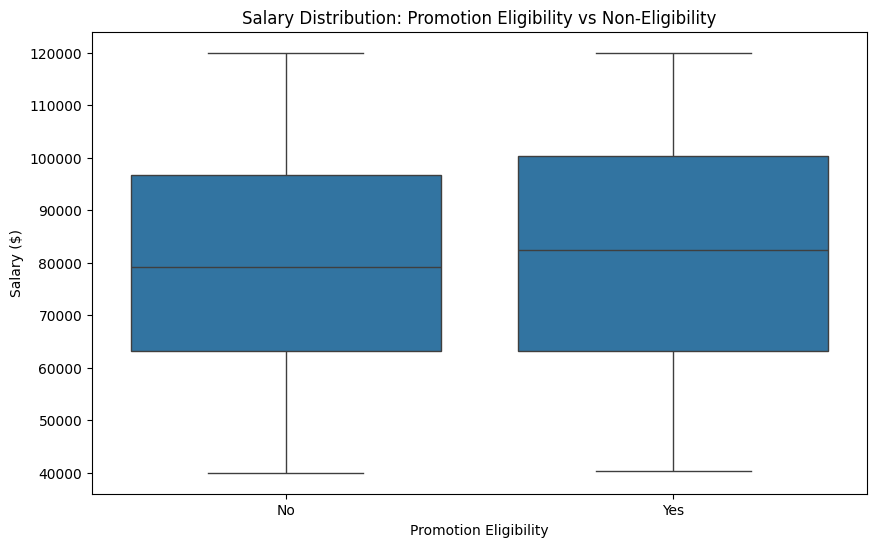

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# iv. Create a boxplot for salary distribution based on promotion eligibility
plt.figure(figsize=(10, 6))
sns.boxplot(x='Promotion Eligibility', y='Salary ($)', data=df)
plt.title('Salary Distribution: Promotion Eligibility vs Non-Eligibility')
plt.show();

In [ ]:
pip install matplotlib seaborn

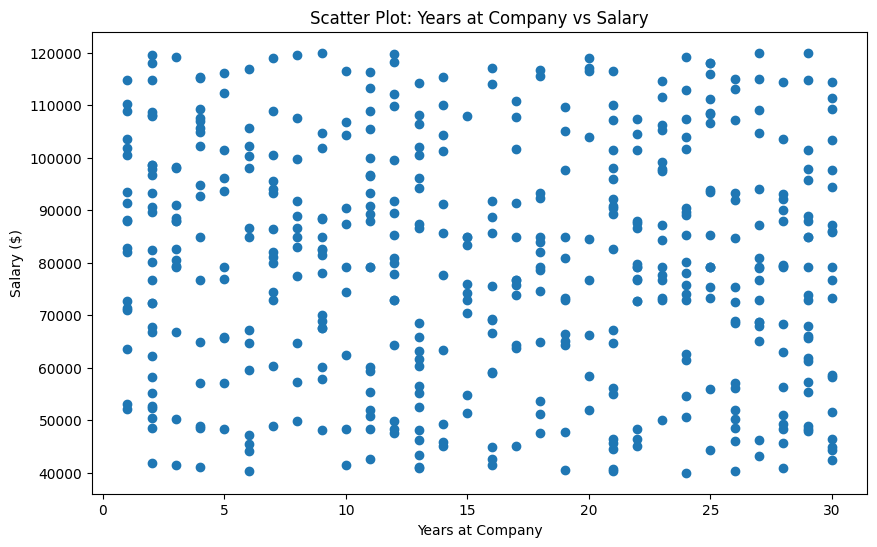

In [ ]:
# v. Examine correlation between Years at Company and Salary
plt.figure(figsize=(10, 6))
plt.scatter(df['Years at Company'], df['Salary ($)'])
plt.title('Scatter Plot: Years at Company vs Salary')
plt.xlabel('Years at Company')
plt.ylabel('Salary ($)')
plt.show()

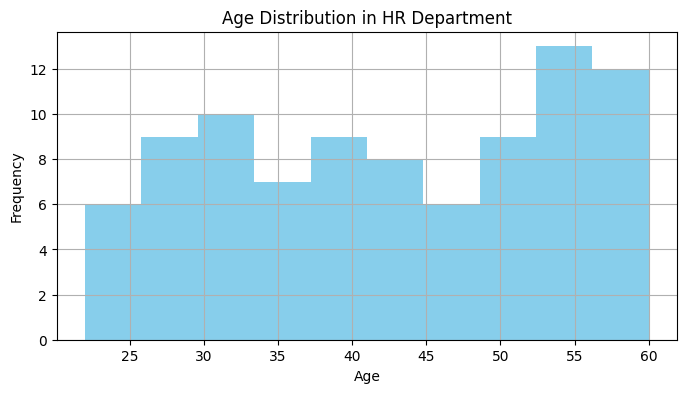

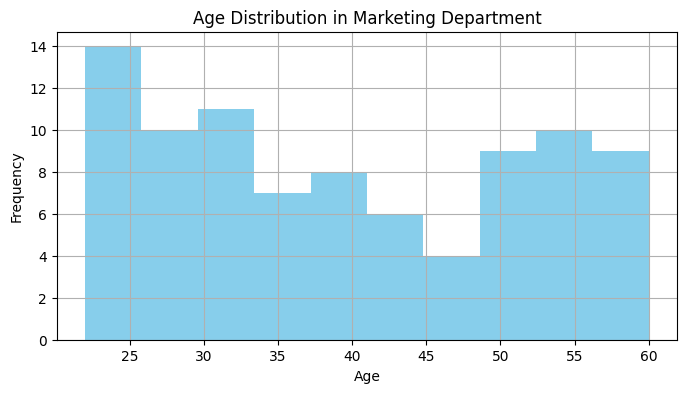

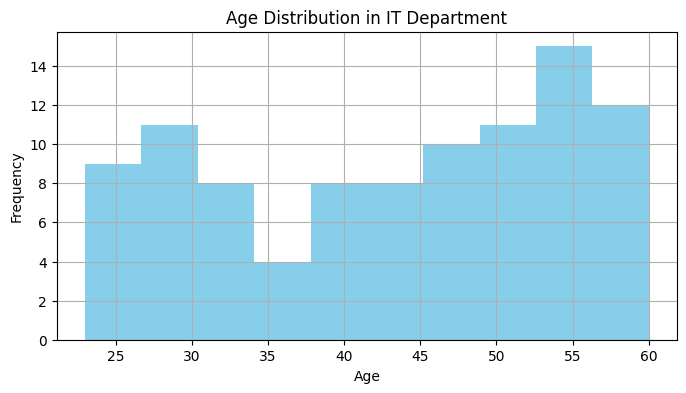

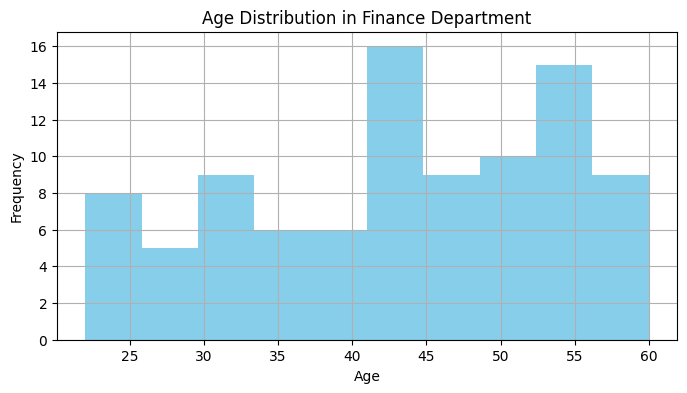

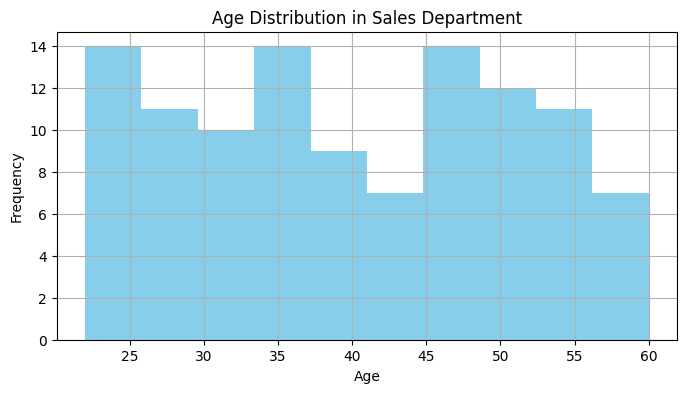

In [ ]:
# Extract unique departments from the DataFrame
departments = df['Department'].unique()

# Loop through each department to visualize age distribution
for dept in departments:
    plt.figure(figsize=(8, 4))
    df[df['Department'] == dept]['Age'].hist(bins=10, color='skyblue')
    plt.title(f'Age Distribution in {dept} Department')
    plt.xlabel('Age')
    plt.ylabel('Frequency')
    plt.show()


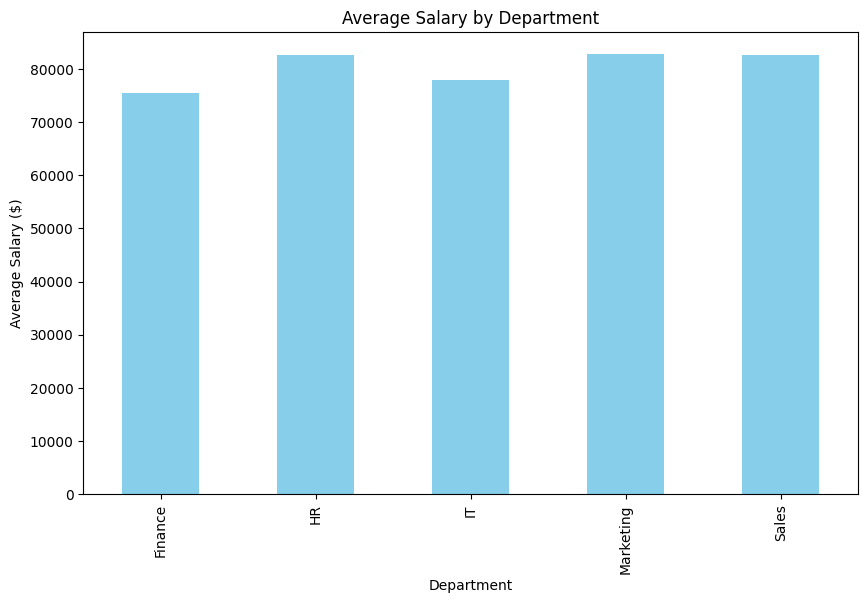

In [ ]:
# i. Bar chart comparing average salaries across departments
dept_salary['mean'].plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary ($)')
plt.show()

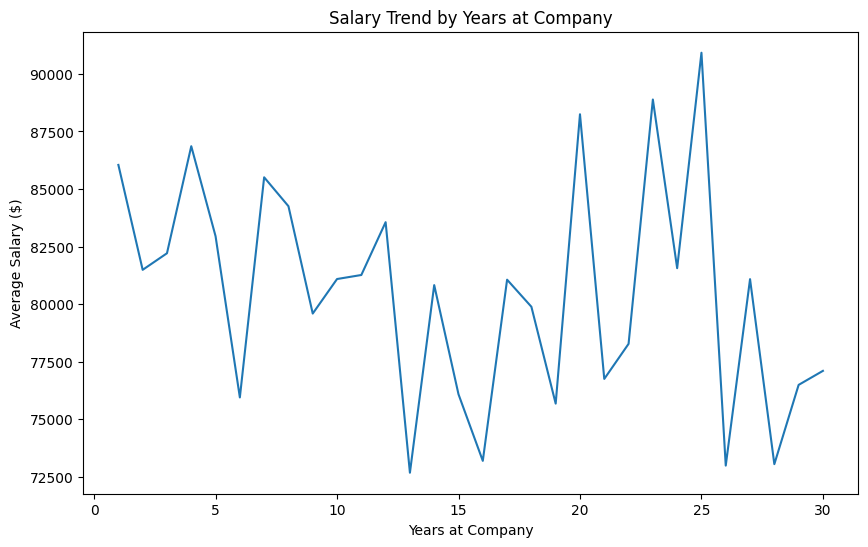

In [ ]:
# ii. Line plot for salary trends based on years at the company
df.groupby('Years at Company')['Salary ($)'].mean().plot(kind='line', figsize=(10, 6))
plt.title('Salary Trend by Years at Company')
plt.xlabel('Years at Company')
plt.ylabel('Average Salary ($)')
plt.show()

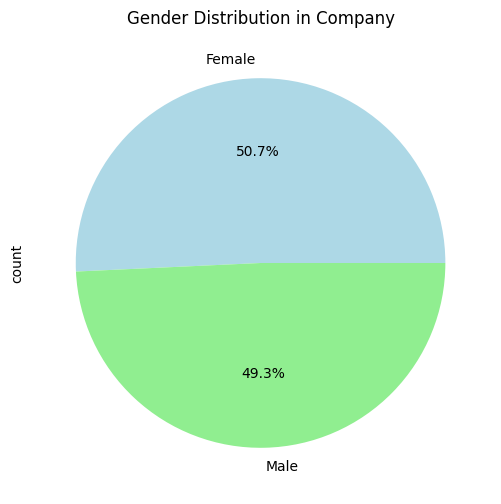

In [ ]:
# iii. Pie chart for gender distribution
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), colors=['lightblue', 'lightgreen'])
plt.title('Gender Distribution in Company')
plt.show()

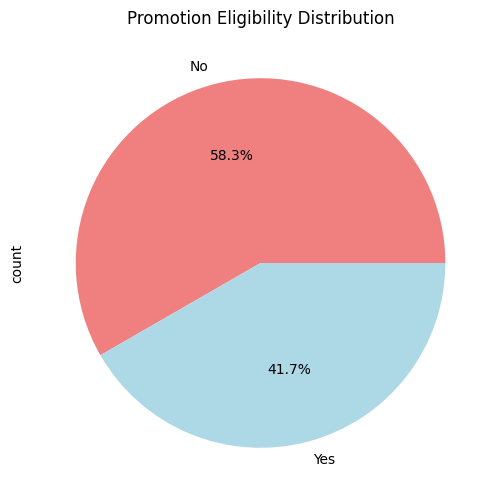

In [ ]:
# iv. Pie chart for promotion eligibility
df['Promotion Eligibility'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), colors=['lightcoral', 'lightblue'])
plt.title('Promotion Eligibility Distribution')
plt.show()


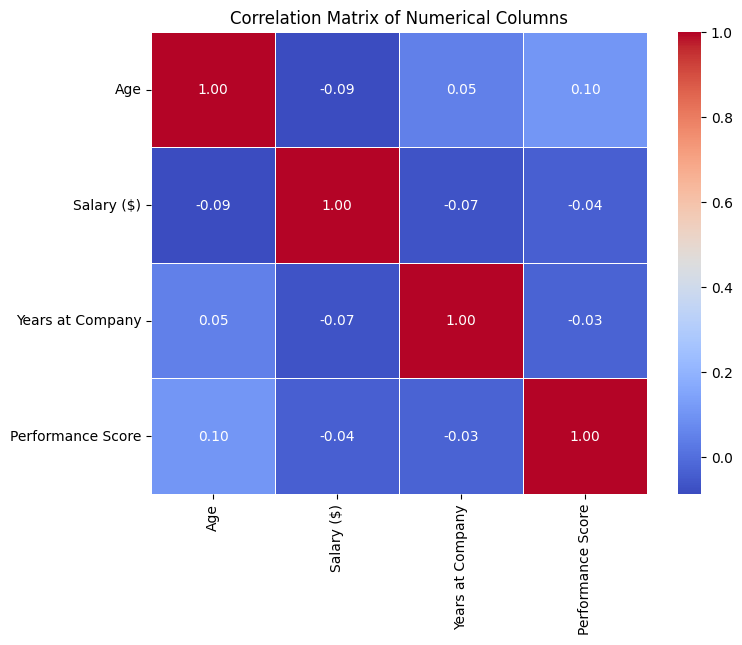

In [ ]:
# Select relevant numerical columns for correlation analysis
numerical_cols = ['Age', 'Salary ($)', 'Years at Company', 'Performance Score']

# Compute the correlation matrix
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Columns')
plt.show()

# Problem # 02

<h3>Part (A): Matrix and Vector Generation</h3>

In [37]:
import numpy as np

# i. Generate a random 5x5 matrix A with values between -10 and 10
A = np.random.uniform(-10, 10, (5, 5))

# ii. Generate a random vector b of length 5 with values between -20 and 20
b = np.random.uniform(-20, 20, 5)

# Display the generated matrix A and vector b
print("Matrix A:")
print(A)
print("\nVector b:")
print(b)


Matrix A:
[[-6.52657546  2.25468072 -8.90256889  9.4913291   7.57272647]
 [ 6.89429961  9.15634164 -7.04987782  5.42924059  0.01193753]
 [ 6.95320676  6.6062131   2.30321098  8.50070551 -2.92516232]
 [ 0.77338223  3.8272912  -9.85805201 -6.41176716  3.95822497]
 [-6.91690706 -5.00256633  6.90419814 -4.50008917  4.28671561]]

Vector b:
[-10.81930611  -7.84606236  18.99574425   8.47139858  -4.43155092]


# Part(B)
<h3>Solution Methods</h3>



In [38]:
import numpy as np

# Assuming A and b are already defined

# i. Explicit Inversion Method
try:
    A_inv = np.linalg.inv(A)  # Calculate the inverse of A
    x_inv = np.dot(A_inv, b)  # Compute x using A^-1 * b
    print("Solution using Explicit Inversion (A^-1 * b):")
    print(x_inv)
except np.linalg.LinAlgError:
    print("Matrix A is singular and cannot be inverted.")

# ii. Recommended Method: np.linalg.solve
try:
    x_solve = np.linalg.solve(A, b)  # Solve Ax = b directly
    print("\nSolution using np.linalg.solve:")
    print(x_solve)
except np.linalg.LinAlgError:
    print("Matrix A is singular and the system cannot be solved.")


Solution using Explicit Inversion (A^-1 * b):
[-708.90113103  639.8675769    37.58490841 -130.26465028 -595.45610686]

Solution using np.linalg.solve:
[-708.90113103  639.8675769    37.58490841 -130.26465028 -595.45610686]


# Explanation:
<h2>Explicit Inversion:</h2>

- First, we calculate the inverse of matrix A using np.linalg.inv().
- Then, we multiply the inverse matrix with the vector 𝑏 to get the solution vector 𝑥.
- The method works, but it's not recommended for larger systems due to potential numerical instability.

<h2>Recommended Method (np.linalg.solve()):</h2>

- This method directly solves the linear system without explicitly computing the inverse of 𝐴
- It is faster and more numerically stable, especially when dealing with large or ill-conditioned matrices.

# Part (C)

<h3>Compare the Two Solution Vectors:</h3>
We can compare the two solution vectors, 𝑥inv (from explicit inversion) and 𝑥solve (from np.linalg.solve), by looking at their absolute differences.

<h3>Calculate the Condition Number</h3>
- The condition number of matrix 𝐴 gives us an idea of how sensitive the solution of 𝐴 𝑥 = 𝑏 Ax=b is to small changes in 𝐴
- A large condition number indicates that the system is ill-conditioned, meaning that small errors in data or computations can lead to large errors in the solution. The condition number is calculated as: <br>
κ(A)=∥A∥⋅∥A −1 ∥ </br>
- A condition number close to 1 means the matrix is well-conditioned, while large values indicate potential numerical instability.

In [39]:
import numpy as np

# Assuming A, b, x_inv, and x_solve are already defined

# i. Compare the two solution vectors
# Compute the absolute difference between the two solutions
diff = np.abs(x_inv - x_solve)

print("Difference between Explicit Inversion and np.linalg.solve solutions:")
print(diff)

# ii. Calculate the condition number of matrix A
condition_number = np.linalg.cond(A)
print(f"\nCondition number of matrix A: {condition_number:.2e}")

# Interpretation of the condition number
if condition_number < 10:
    print("The matrix is well-conditioned (numerically stable).")
elif condition_number < 1000:
    print("The matrix is moderately conditioned (some numerical instability).")
else:
    print("The matrix is ill-conditioned (numerically unstable).")


Difference between Explicit Inversion and np.linalg.solve solutions:
[1.13686838e-13 0.00000000e+00 7.10542736e-15 2.84217094e-14
 0.00000000e+00]

Condition number of matrix A: 1.33e+03
The matrix is ill-conditioned (numerically unstable).


# Explanation:
<h3>Comparison of Solutions:</h3>

- The diff array will give the element-wise absolute differences between the two solution vectors. Ideally, if both methods are stable and accurate, the differences should be very small, indicating that the methods give consistent results.

<h3>Condition Number:</h3>

- The condition number is a measure of how sensitive the solution is to changes in the matrix 𝐴. A high condition number indicates that even small errors in
𝐴 or 𝑏 could lead to large errors in 𝑥.
- Well-conditioned systems have condition numbers close to 1, meaning they are stable and reliable.
- Ill-conditioned systems (with high condition numbers) are prone to instability and errors, meaning that small changes in the data (such as rounding errors) can significantly affect the solution.

# Part (D): Advanced Visualizations
<h3>i. 3D Surface Plot for 𝐴𝑥=𝑏</h3>
Ax=b
We can visualize the system of equations 𝐴𝑥=𝑏 in a 3D space. Since we're working with a 5x5 system, it’s not possible to fully visualize all five dimensions, but we can represent a simplified version of it by projecting it onto a 3D plane using a subset of variables. We'll focus on three variables for simplicity.

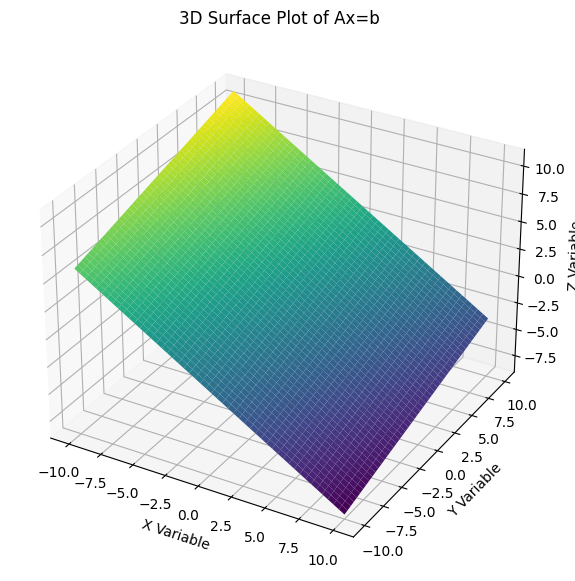

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Assuming A, b, and x_solve are already defined

# Create a meshgrid for 3D visualization (simplified to 3 variables)
x = np.linspace(-10, 10, 50)
y = np.linspace(-10, 10, 50)
X, Y = np.meshgrid(x, y)

# Solve for Z based on the equation Ax = b (focusing on 3 variables for visualization)
Z = (b[0] - A[0, 0] * X - A[0, 1] * Y) / A[0, 2]

# 3D Surface Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')

# Labels
ax.set_xlabel('X Variable')
ax.set_ylabel('Y Variable')
ax.set_zlabel('Z Variable')
ax.set_title('3D Surface Plot of Ax=b')

plt.show()


# Question #03
<h3>Part (A): Dataset Creation</h3>


In [2]:
import numpy as np
import pandas as pd

# Generating the dataset for the last 50 years (from 1970 to 2020)
years = np.arange(1970, 2021)
avg_temp = np.random.normal(15, 0.5, len(years)) + 0.02 * (years - 1970)  # Increasing trend in temperature
co2_levels = np.random.normal(350, 10, len(years)) + 1.5 * (years - 1970)  # Increasing trend in CO2 levels
sea_level_rise = np.random.normal(0, 10, len(years)) + 0.1 * (years - 1970)  # Gradual sea level rise

# Create a DataFrame
climate_data = pd.DataFrame({
    "Year": years,
    "Average Temperature (°C)": avg_temp,
    "CO2 Levels (ppm)": co2_levels,
    "Average Sea Level Rise (mm)": sea_level_rise
})


<h3>Part (B): Visualizations</h3>

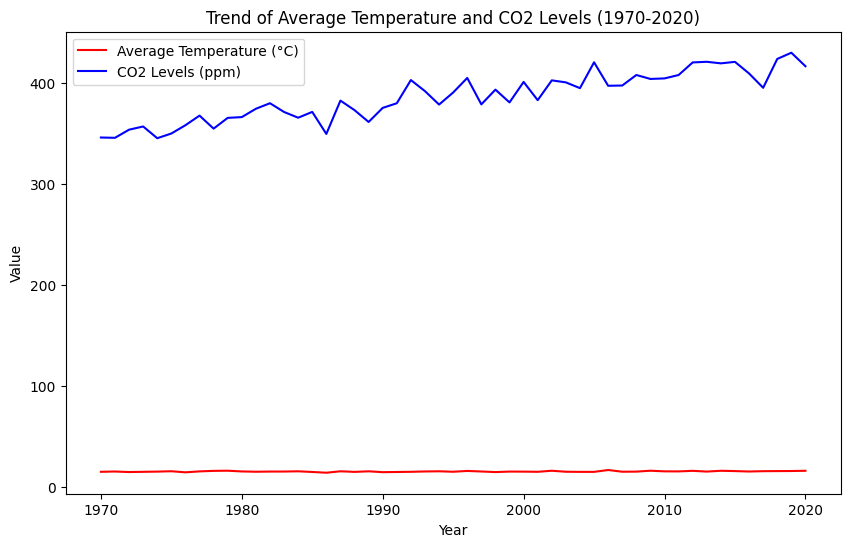

In [3]:
import matplotlib.pyplot as plt

# Line plot for Temperature and CO2 levels over the years
plt.figure(figsize=(10, 6))
plt.plot(climate_data['Year'], climate_data['Average Temperature (°C)'], label="Average Temperature (°C)", color='r')
plt.plot(climate_data['Year'], climate_data['CO2 Levels (ppm)'], label="CO2 Levels (ppm)", color='b')

# Labels, title, and legend
plt.title('Trend of Average Temperature and CO2 Levels (1970-2020)')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()
plt.show()

# Discuss any correlation: As CO2 levels rise over time, we see a corresponding rise in average temperature.


<h3>ii. Scatter Plot with Linear Regression Line (CO2 Levels vs. Average Sea Level Rise)</h3>

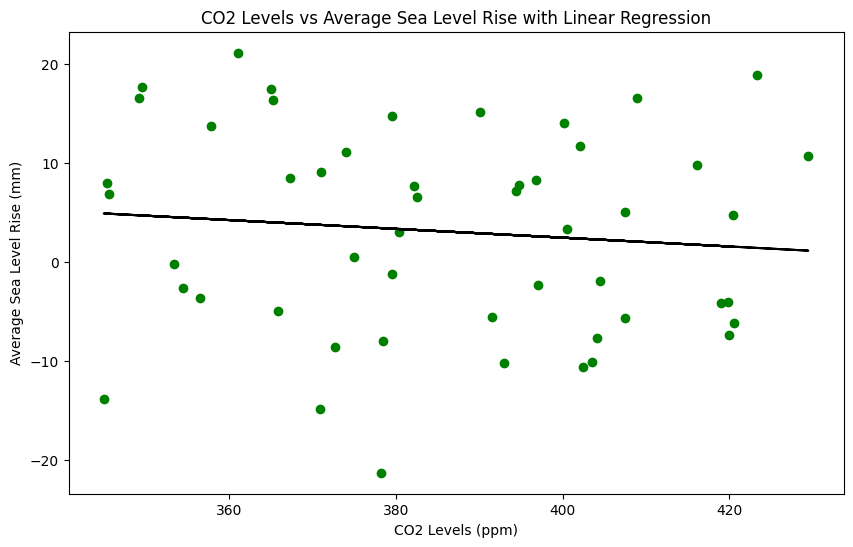

In [4]:
# Scatter plot for CO2 Levels vs Average Sea Level Rise
plt.figure(figsize=(10, 6))
plt.scatter(climate_data['CO2 Levels (ppm)'], climate_data['Average Sea Level Rise (mm)'], color='g')

# Fit a linear regression line using np.polyfit
slope, intercept = np.polyfit(climate_data['CO2 Levels (ppm)'], climate_data['Average Sea Level Rise (mm)'], 1)
plt.plot(climate_data['CO2 Levels (ppm)'], slope * climate_data['CO2 Levels (ppm)'] + intercept, color='black')

# Labels and title
plt.title('CO2 Levels vs Average Sea Level Rise with Linear Regression')
plt.xlabel('CO2 Levels (ppm)')
plt.ylabel('Average Sea Level Rise (mm)')
plt.show()

# Discuss significance: The linear regression line indicates a positive relationship, suggesting that as CO2 levels increase, sea levels also tend to rise.


<h3>iii. Histogram of Average Temperature</h3>

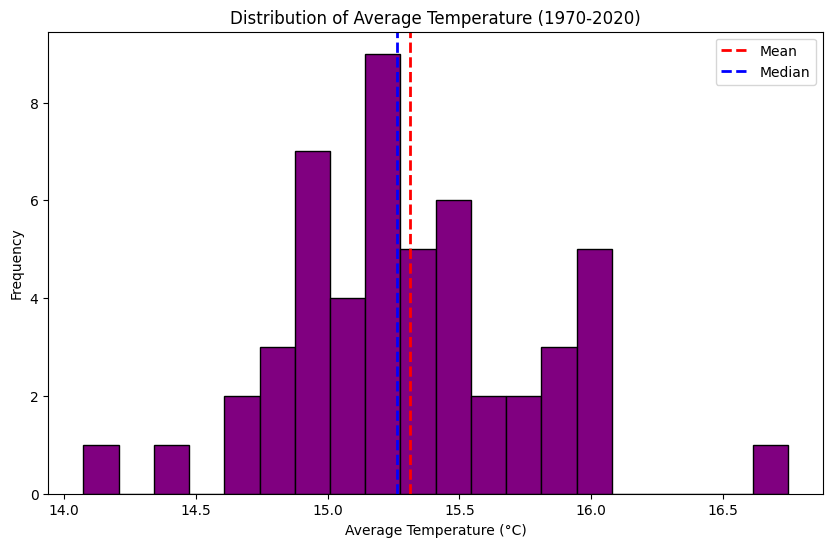

In [5]:
# Histogram of Average Temperature
plt.figure(figsize=(10, 6))
plt.hist(climate_data['Average Temperature (°C)'], bins=20, color='purple', edgecolor='black')

# Mean and median lines
plt.axvline(climate_data['Average Temperature (°C)'].mean(), color='red', linestyle='dashed', linewidth=2, label="Mean")
plt.axvline(climate_data['Average Temperature (°C)'].median(), color='blue', linestyle='dashed', linewidth=2, label="Median")

# Labels and title
plt.title('Distribution of Average Temperature (1970-2020)')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Customization of bins allows more granular analysis, and the mean/median lines provide insights into temperature distribution.


<h3>iv. Box Plot to Compare Sea Level Rise Across Two Decades</h3>

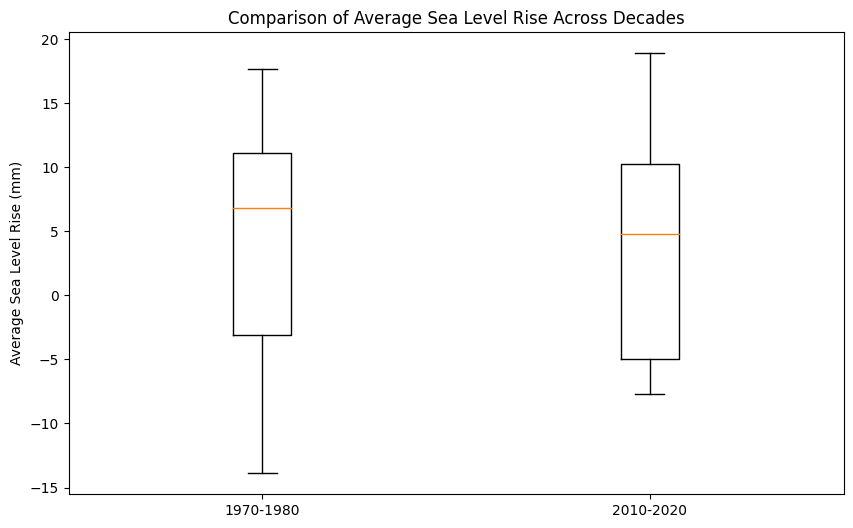

In [6]:
# Extract data for two decades: 1970-1980 and 2010-2020
decade_1 = climate_data[(climate_data['Year'] >= 1970) & (climate_data['Year'] <= 1980)]['Average Sea Level Rise (mm)']
decade_2 = climate_data[(climate_data['Year'] >= 2010) & (climate_data['Year'] <= 2020)]['Average Sea Level Rise (mm)']

# Box plot
plt.figure(figsize=(10, 6))
plt.boxplot([decade_1, decade_2], labels=["1970-1980", "2010-2020"])

# Labels and title
plt.title('Comparison of Average Sea Level Rise Across Decades')
plt.ylabel('Average Sea Level Rise (mm)')
plt.show()

# Analyze: The box plot will reveal differences in the distribution of sea level rise across the two decades, likely showing an increase in the recent decade.


<h3>v. Heatmap of Correlation Matrix</h3>

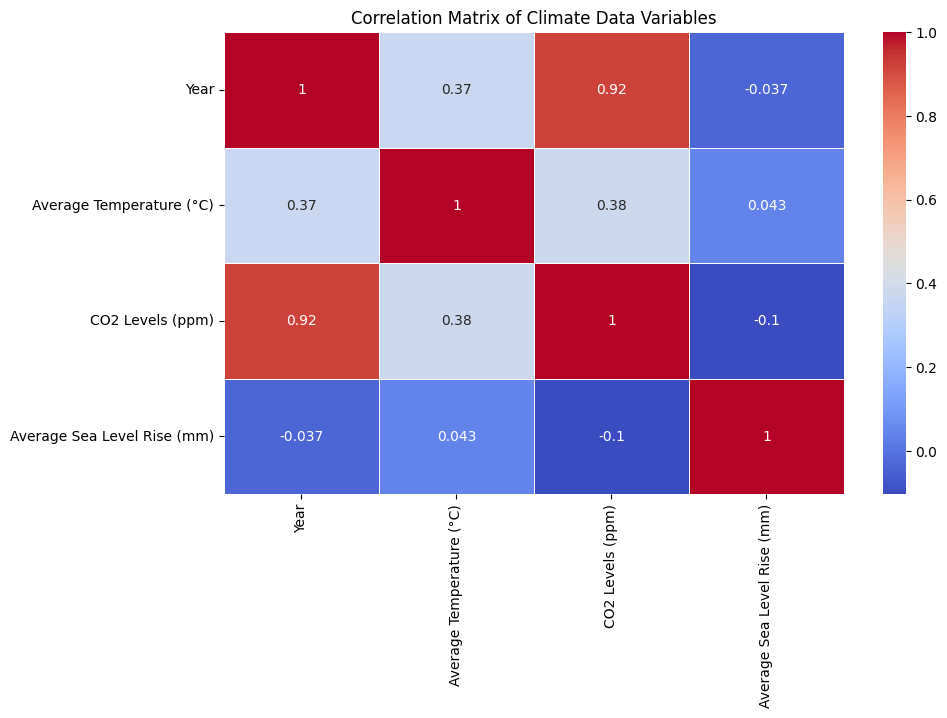

In [7]:
import seaborn as sns

# Compute correlation matrix
corr_matrix = climate_data.corr()

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

# Title
plt.title('Correlation Matrix of Climate Data Variables')
plt.show()

# Highlight any strong correlations: We expect a strong correlation between CO2 levels and temperature/sea level rise.


<h3>vi. 3D Scatter Plot (Average Temperature, CO2 Levels, and Sea Level Rise)</h3>

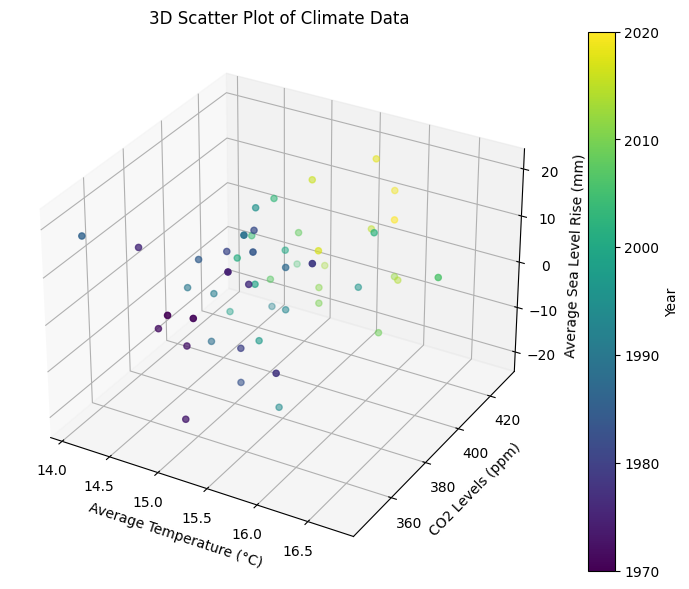

In [8]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 3D scatter plot
sc = ax.scatter(climate_data['Average Temperature (°C)'], climate_data['CO2 Levels (ppm)'],
                climate_data['Average Sea Level Rise (mm)'], c=climate_data['Year'], cmap='viridis')

# Axes labels
ax.set_xlabel('Average Temperature (°C)')
ax.set_ylabel('CO2 Levels (ppm)')
ax.set_zlabel('Average Sea Level Rise (mm)')
ax.set_title('3D Scatter Plot of Climate Data')

# Add color bar for years
plt.colorbar(sc, label='Year')

plt.show()

# Observation: The color coding by year allows us to see how relationships evolve over time.


<h3>vii. Pie Chart for CO2 Contributions</h3>

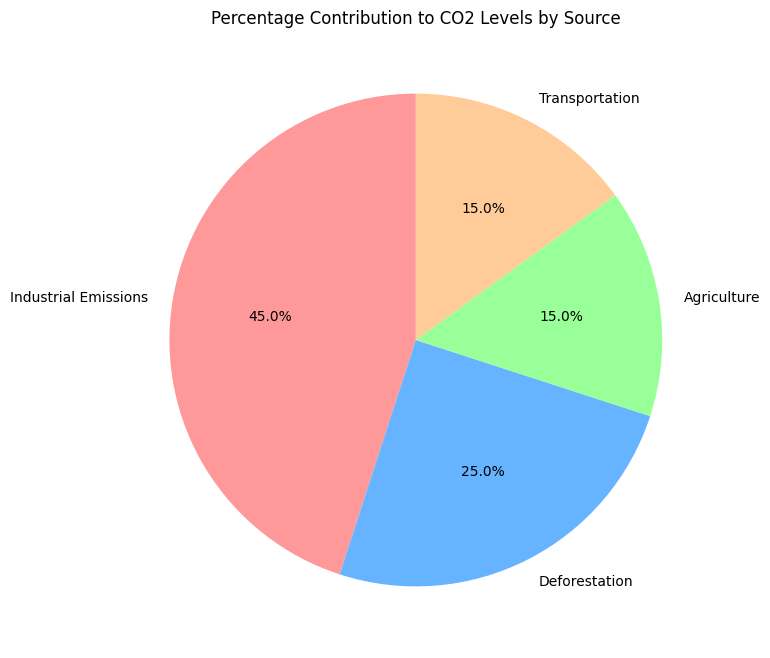

In [9]:
# Sample data for CO2 contributions
co2_sources = ['Industrial Emissions', 'Deforestation', 'Agriculture', 'Transportation']
contributions = [45, 25, 15, 15]

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(contributions, labels=co2_sources, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'], startangle=90)
plt.title('Percentage Contribution to CO2 Levels by Source')
plt.show()

# Discuss: The pie chart highlights how different human activities contribute to rising CO2 levels, impacting climate change.


<h3>viii. Subplot Grid</h3>

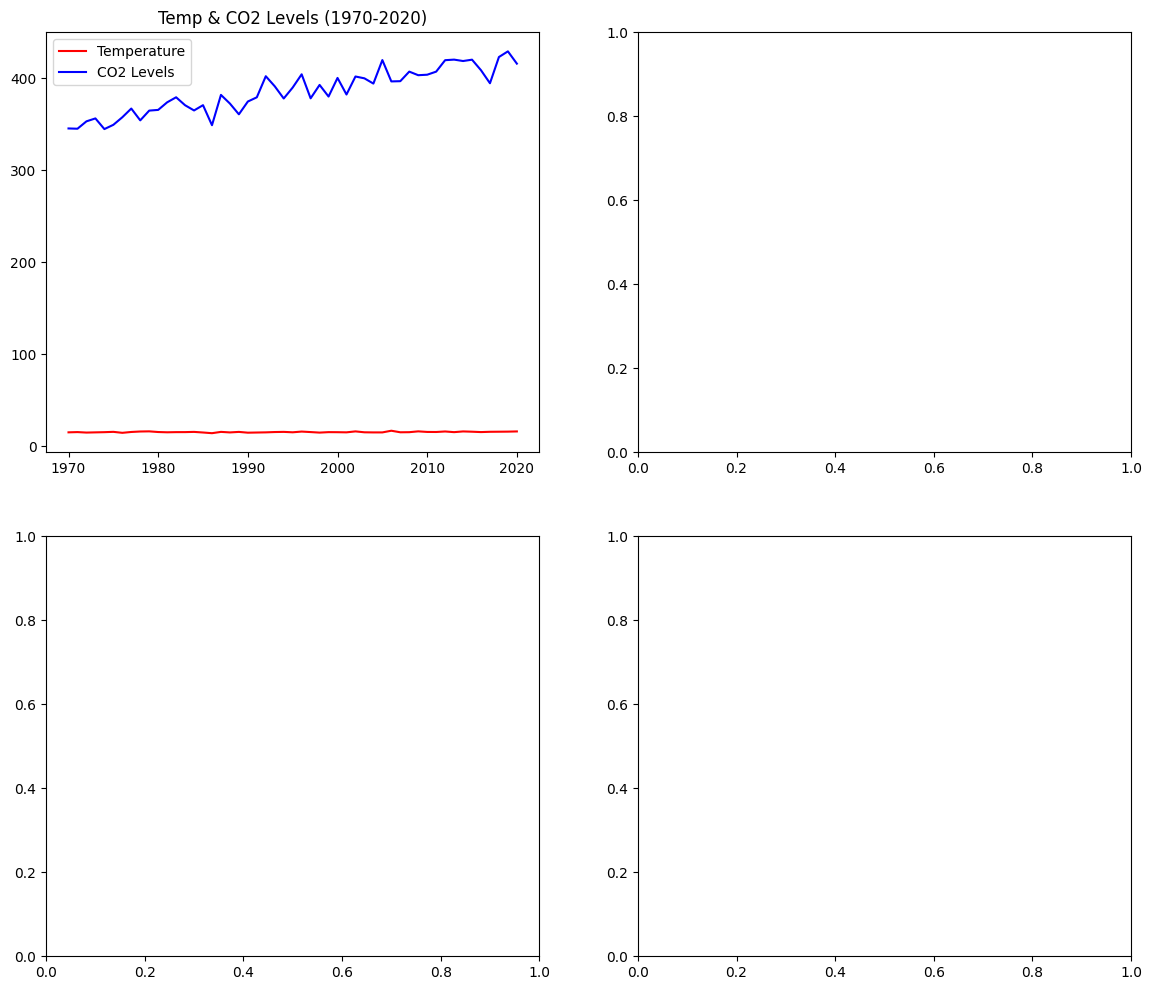

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Line plot in subplot 1
axs[0, 0].plot(climate_data['Year'], climate_data['Average Temperature (°C)'], label="Temperature", color='r')
axs[0, 0].plot(climate_data['Year'], climate_data['CO2 Levels (ppm)'], label="CO2 Levels", color='b')
axs[0, 0].set_title('Temp & CO2 Levels (1970-2020)')
axs[0, 0].legend()

# Scatter plot in subplot 2
